In [ ]:
# Install necessary libraries
!pip install timm grad-cam scikit-learn seaborn matplotlib

import os
import zipfile
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/ELPV_Dataset.zip'
extract_path = '/content/elpv_data'

if not os.path.exists(extract_path):
    print("Extracting dataset")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete!")

dataset_root = extract_path
csv_path = os.path.join(extract_path, 'labels.csv')

if not os.path.exists(csv_path):
    found = False
    for root, dirs, files in os.walk(extract_path):
        if 'labels.csv' in files:
            csv_path = os.path.join(root, 'labels.csv')
            dataset_root = root
            found = True
            break
    if not found:
        raise FileNotFoundError("Could not find labels.csv! Check your zip file structure.")

print(f" Found CSV at: {csv_path}")
print(f" Dataset Root set to: {dataset_root}")

class ELPVDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx, 0]

        full_img_path = os.path.join(self.root_dir, img_name)
        if not os.path.exists(full_img_path):
             full_img_path = os.path.join(self.root_dir, 'images', os.path.basename(img_name))


        if not os.path.exists(full_img_path):
            raise FileNotFoundError(f"Image not found: {full_img_path}")

        image = Image.open(full_img_path).convert('RGB')

        prob = self.df.iloc[idx, 1]
        if prob == 0.0:
            label = 0
        elif prob == 0.33:
            label = 1
        else:
            label = 2

        if self.transform:
            image = self.transform(image)

        return image, label

df = pd.read_csv(csv_path, header=None, names=['image', 'prob', 'type'])

y_temp = []
for p in df['prob']:
    if p == 0.0: y_temp.append(0)
    elif p == 0.33: y_temp.append(1)
    else: y_temp.append(2)
df['class_label'] = y_temp

train_df, test_val_df = train_test_split(df, test_size=0.3, stratify=df['class_label'], random_state=42)
val_df, test_df = train_test_split(test_val_df, test_size=0.5, stratify=test_val_df['class_label'], random_state=42)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

class_counts = train_df['class_label'].value_counts().sort_index()
class_weights = 1. / class_counts
sample_weights = train_df['class_label'].apply(lambda x: class_weights[x])
sampler = WeightedRandomSampler(weights=sample_weights.values, num_samples=len(train_df), replacement=True)

stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

train_ds = ELPVDataset(train_df, dataset_root, transform=train_transform)
val_ds = ELPVDataset(val_df, dataset_root, transform=test_transform)
test_ds = ELPVDataset(test_df, dataset_root, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print("Data Setup Complete. Classes mapped to 0 (No), 1 (Mild), 2 (Severe).")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Found CSV at: /content/elpv_data/labels.csv
 Dataset Root set to: /content/elpv_data
Train size: 1836
Val size: 394
Test size: 394
Data Setup Complete. Classes mapped to 0 (No), 1 (Mild), 2 (Severe).


In [ ]:
import os
import glob
from torch.utils.data import DataLoader, WeightedRandomSampler

print(" Hunting for the real image location...")
found_images = glob.glob('/content/elpv_data/**/cell0001.png', recursive=True)

if not found_images:
    raise FileNotFoundError(" CRITICAL: Could not find cell0001.png anywhere! Check your zip file.")

real_image_path = os.path.dirname(found_images[0])
print(f" FOUND THEM! Images are hiding here: {real_image_path}")

class ELPVDataset_Fixed(Dataset):
    def __init__(self, dataframe, real_img_dir, transform=None):
        self.df = dataframe
        self.real_img_dir = real_img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        csv_name = self.df.iloc[idx, 0]
        filename = os.path.basename(csv_name)
        full_path = os.path.join(self.real_img_dir, filename)

        image = Image.open(full_path).convert('RGB')

        # Map Labels
        prob = self.df.iloc[idx, 1]
        if prob == 0.0: label = 0
        elif prob == 0.33: label = 1
        else: label = 2

        if self.transform:
            image = self.transform(image)

        return image, label

print(" Re-building DataLoaders with fixed paths...")

train_ds = ELPVDataset_Fixed(train_df, real_image_path, transform=train_transform)
val_ds = ELPVDataset_Fixed(val_df, real_image_path, transform=test_transform)
test_ds = ELPVDataset_Fixed(test_df, real_image_path, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print(" FIX COMPLETE")

 Hunting for the real image location...
 FOUND THEM! Images are hiding here: /content/elpv_data/images/images
 Re-building DataLoaders with fixed paths...
 FIX COMPLETE


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-790632558.py:38: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(csv_path, delim_whitespace=True, header=None, names=['image', 'prob', 'type'])


resnet50 Epoch 1/15 Val Acc: 61.17%
resnet50 Epoch 2/15 Val Acc: 63.71%
resnet50 Epoch 3/15 Val Acc: 72.08%
resnet50 Epoch 4/15 Val Acc: 63.96%
resnet50 Epoch 5/15 Val Acc: 72.08%
resnet50 Epoch 6/15 Val Acc: 72.34%
resnet50 Epoch 7/15 Val Acc: 70.30%
resnet50 Epoch 8/15 Val Acc: 72.84%
resnet50 Epoch 9/15 Val Acc: 73.35%
resnet50 Epoch 10/15 Val Acc: 67.77%
resnet50 Epoch 11/15 Val Acc: 68.02%
resnet50 Epoch 12/15 Val Acc: 75.63%
resnet50 Epoch 13/15 Val Acc: 70.56%
resnet50 Epoch 14/15 Val Acc: 69.29%
resnet50 Epoch 15/15 Val Acc: 73.60%


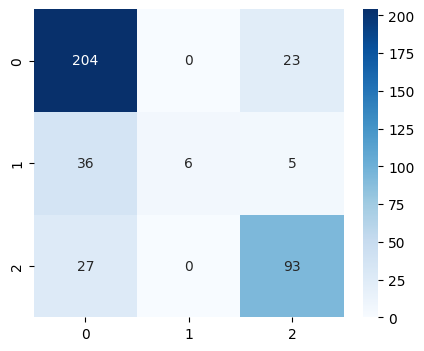

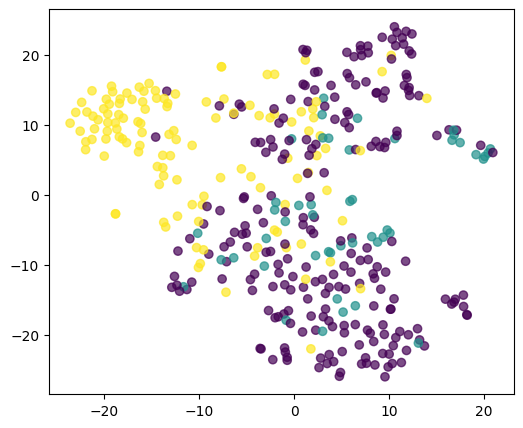

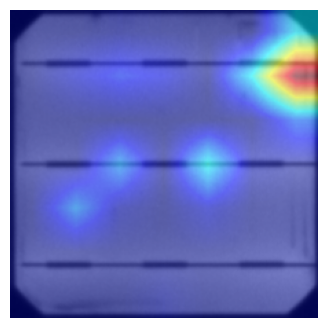

In [ ]:
import os
import glob
import zipfile
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import timm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from google.colab import drive

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/ELPV_Dataset.zip'
extract_path = '/content/elpv_data'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

csv_files = glob.glob(os.path.join(extract_path, '**', 'labels.csv'), recursive=True)
csv_path = csv_files[0]

img_files = glob.glob(os.path.join(extract_path, '**', 'cell0001.png'), recursive=True)
real_img_dir = os.path.dirname(img_files[0])

df = pd.read_csv(csv_path, delim_whitespace=True, header=None, names=['image', 'prob', 'type'])
df = df.dropna()
df['image'] = df['image'].astype(str).apply(lambda x: os.path.basename(x))

class ELPVDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        filename = self.df.iloc[idx, 0]
        full_path = os.path.join(self.root_dir, filename)
        image = Image.open(full_path).convert('RGB')

        # --- THE FIX IS HERE ---
        prob = float(self.df.iloc[idx, 1]) # Ensure it's a float

        if prob == 0.0:
            label = 0      # No Defect
        elif prob < 0.5:   # Catch 0.333333... (Mild)
            label = 1      # Mild
        else:              # Catch 0.66... and 1.0 (Severe)
            label = 2      # Severe
        # -----------------------

        if self.transform: image = self.transform(image)
        return image, label

y_temp = []
for p in df['prob']:
    if p == 0.0:
        y_temp.append(0)
    elif p == 0.33:
        y_temp.append(1)
    else:
        y_temp.append(2)
df['class_label'] = y_temp

train_df, test_val_df = train_test_split(df, test_size=0.3, stratify=df['class_label'], random_state=42)
val_df, test_df = train_test_split(test_val_df, test_size=0.5, stratify=test_val_df['class_label'], random_state=42)

class_weights = 1. / train_df['class_label'].value_counts().sort_index()
sample_weights = train_df['class_label'].apply(lambda x: class_weights[x])
sampler = WeightedRandomSampler(weights=sample_weights.values, num_samples=len(train_df), replacement=True)

stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])
test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

train_loader = DataLoader(ELPVDataset(train_df, real_img_dir, train_tf), batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(ELPVDataset(val_df, real_img_dir, test_tf), batch_size=32, shuffle=False)
test_loader = DataLoader(ELPVDataset(test_df, real_img_dir, test_tf), batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_and_evaluate(model_name):
    model = timm.create_model(model_name, pretrained=True, num_classes=3).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    best_acc = 0.0

    for epoch in range(15):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                total += lbls.size(0)
                correct += (preds == lbls).sum().item()

        acc = 100 * correct / total
        print(f"{model_name} Epoch {epoch+1}/15 Val Acc: {acc:.2f}%")

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), f"{model_name}_best.pth")

    return model

def run_visualizations(model_name):
    model = timm.create_model(model_name, pretrained=False, num_classes=3).to(device)
    model.load_state_dict(torch.load(f"{model_name}_best.pth"))
    model.eval()

    all_preds, all_lbls, features = [], [], []

    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            feats = model.forward_features(imgs)
            if len(feats.shape) == 4:
                feats = feats.mean(dim=[2,3])
            features.append(feats.cpu().numpy())
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_lbls.extend(lbls.numpy())

    cm = confusion_matrix(all_lbls, all_preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.show()

    features = np.concatenate(features)
    tsne = TSNE(n_components=2, random_state=42).fit_transform(features)
    plt.figure(figsize=(6,5))
    plt.scatter(tsne[:,0], tsne[:,1], c=all_lbls, cmap='viridis', alpha=0.7)
    plt.show()

    try:
        if 'resnet' in model_name: target = [model.layer4[-1]]
        elif 'efficient' in model_name: target = [model.blocks[-1]]
        elif 'convnext' in model_name: target = [model.stages[-1]]

        cam = GradCAM(model=model, target_layers=target)
        img_tensor, label = ELPVDataset(test_df[test_df['class_label']==2], real_img_dir, test_tf)[0]
        input_tensor = img_tensor.unsqueeze(0).to(device)
        grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(2)])[0]

        rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
        rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

        viz = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        plt.figure(figsize=(4,4))
        plt.imshow(viz)
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(e)

train_and_evaluate('resnet50')
run_visualizations('resnet50')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

efficientnet_b0 Epoch 1/15 Val Acc: 60.15%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ba82cba1620>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ba82cba1620>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

efficientnet_b0 Epoch 2/15 Val Acc: 65.23%
efficientnet_b0 Epoch 3/15 Val Acc: 65.74%
efficientnet_b0 Epoch 4/15 Val Acc: 66.24%
efficientnet_b0 Epoch 5/15 Val Acc: 65.99%
efficientnet_b0 Epoch 6/15 Val Acc: 67.51%
efficientnet_b0 Epoch 7/15 Val Acc: 72.34%
efficientnet_b0 Epoch 8/15 Val Acc: 74.11%
efficientnet_b0 Epoch 9/15 Val Acc: 71.32%
efficientnet_b0 Epoch 10/15 Val Acc: 71.32%
efficientnet_b0 Epoch 11/15 Val Acc: 74.11%
efficientnet_b0 Epoch 12/15 Val Acc: 74.37%
efficientnet_b0 Epoch 13/15 Val Acc: 72.59%
efficientnet_b0 Epoch 14/15 Val Acc: 71.57%
efficientnet_b0 Epoch 15/15 Val Acc: 74.62%


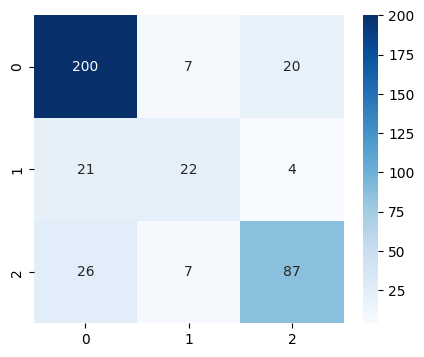

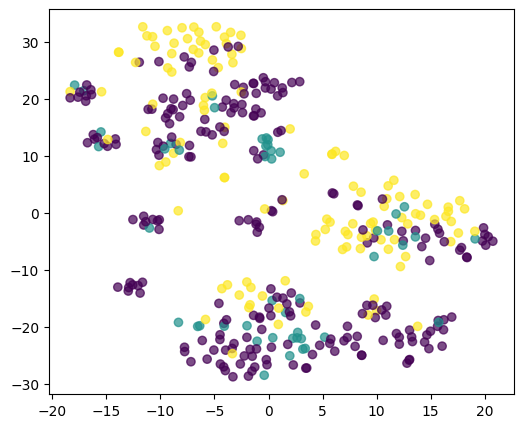

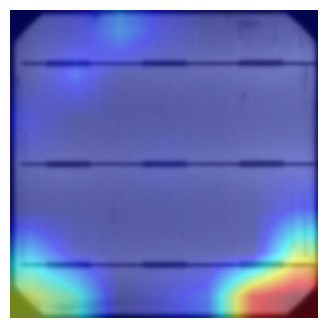

In [ ]:
train_and_evaluate('efficientnet_b0')
run_visualizations('efficientnet_b0')

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

convnext_tiny Epoch 1/15 Val Acc: 66.24%
convnext_tiny Epoch 2/15 Val Acc: 72.34%
convnext_tiny Epoch 3/15 Val Acc: 72.84%
convnext_tiny Epoch 4/15 Val Acc: 74.87%
convnext_tiny Epoch 5/15 Val Acc: 75.89%
convnext_tiny Epoch 6/15 Val Acc: 75.38%
convnext_tiny Epoch 7/15 Val Acc: 72.34%
convnext_tiny Epoch 8/15 Val Acc: 72.08%
convnext_tiny Epoch 9/15 Val Acc: 77.92%
convnext_tiny Epoch 10/15 Val Acc: 75.89%
convnext_tiny Epoch 11/15 Val Acc: 78.43%
convnext_tiny Epoch 12/15 Val Acc: 78.17%
convnext_tiny Epoch 13/15 Val Acc: 80.20%
convnext_tiny Epoch 14/15 Val Acc: 80.71%
convnext_tiny Epoch 15/15 Val Acc: 79.95%


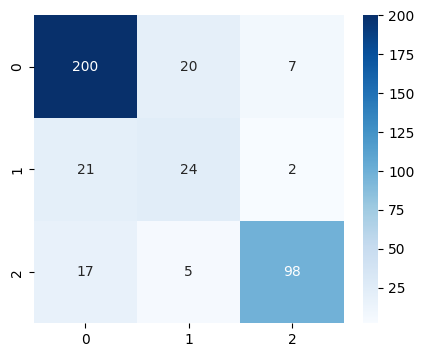

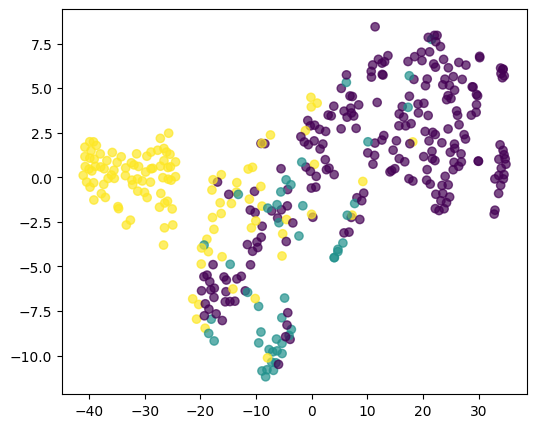

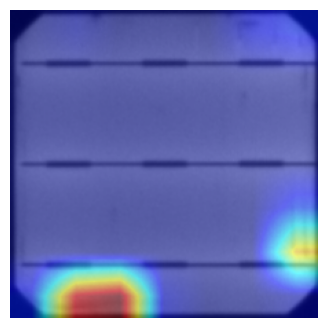

In [ ]:
train_and_evaluate('convnext_tiny')
run_visualizations('convnext_tiny')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 CSV Found: /content/elpv_data/labels.csv
 Images Found: /content/elpv_data/images/images

 TRAINING: VIT_TINY


/tmp/ipython-input-754615010.py:47: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(csv_path, delim_whitespace=True, header=None, names=['image', 'prob', 'type'])


vit_tiny Epoch 1/15 Val Acc: 72.08%
vit_tiny Epoch 2/15 Val Acc: 73.35%
vit_tiny Epoch 3/15 Val Acc: 74.62%
vit_tiny Epoch 4/15 Val Acc: 76.65%
vit_tiny Epoch 5/15 Val Acc: 77.66%
vit_tiny Epoch 6/15 Val Acc: 74.87%
vit_tiny Epoch 7/15 Val Acc: 77.41%
vit_tiny Epoch 8/15 Val Acc: 76.90%
vit_tiny Epoch 9/15 Val Acc: 75.89%
vit_tiny Epoch 10/15 Val Acc: 78.93%
vit_tiny Epoch 11/15 Val Acc: 79.19%
vit_tiny Epoch 12/15 Val Acc: 76.90%
vit_tiny Epoch 13/15 Val Acc: 79.44%
vit_tiny Epoch 14/15 Val Acc: 78.17%
vit_tiny Epoch 15/15 Val Acc: 79.44%
 Best Accuracy for vit_tiny: 79.44%

 GENERATING VIZ FOR vit_tiny...


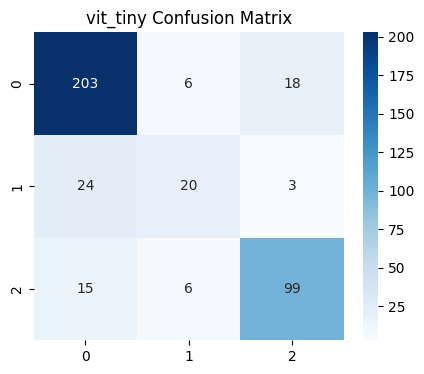

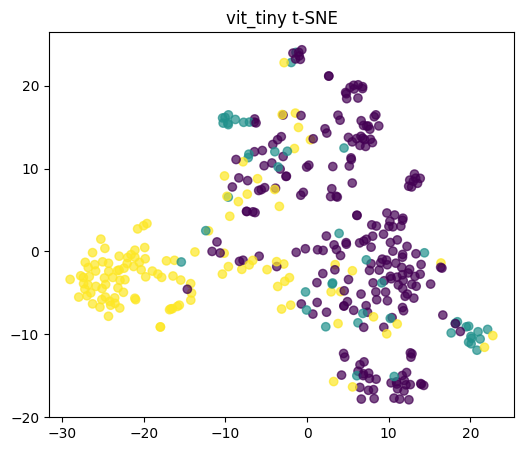

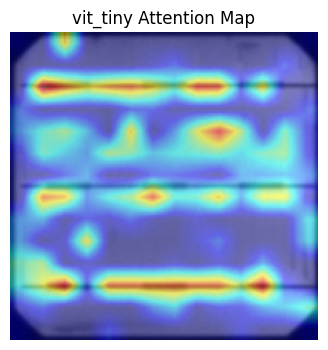

In [ ]:

import os
import glob
import zipfile
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import timm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from google.colab import drive


drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/elpv(91).zip'
extract_path = '/content/elpv_data'

if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)


csv_files = glob.glob(os.path.join(extract_path, '**', 'labels.csv'), recursive=True)
if not csv_files: raise FileNotFoundError(" Could not find labels.csv!")
csv_path = csv_files[0]


img_files = glob.glob(os.path.join(extract_path, '**', 'cell0001.png'), recursive=True)
if not img_files: raise FileNotFoundError(" Could not find images!")
real_img_dir = os.path.dirname(img_files[0])

print(f" CSV Found: {csv_path}")
print(f" Images Found: {real_img_dir}")


df = pd.read_csv(csv_path, delim_whitespace=True, header=None, names=['image', 'prob', 'type'])
df = df.dropna()
df['image'] = df['image'].astype(str).apply(lambda x: os.path.basename(x))


class ELPVDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        filename = self.df.iloc[idx, 0]
        full_path = os.path.join(self.root_dir, filename)
        image = Image.open(full_path).convert('RGB')


        prob = float(self.df.iloc[idx, 1])

        if prob == 0.0:
            label = 0
        elif prob < 0.5:
            label = 1
        else:
            label = 2


        if self.transform: image = self.transform(image)
        return image, label


y_temp = [0 if p==0.0 else 1 if p==0.33 else 2 for p in df['prob']]
df['class_label'] = y_temp

train_df, test_val_df = train_test_split(df, test_size=0.3, stratify=df['class_label'], random_state=42)
val_df, test_df = train_test_split(test_val_df, test_size=0.5, stratify=test_val_df['class_label'], random_state=42)


class_weights = 1. / train_df['class_label'].value_counts().sort_index()
sample_weights = train_df['class_label'].apply(lambda x: class_weights[x])
sampler = WeightedRandomSampler(weights=sample_weights.values, num_samples=len(train_df), replacement=True)


stats = ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])
test_tf = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(*stats)])


train_loader = DataLoader(ELPVDataset(train_df, real_img_dir, train_tf), batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(ELPVDataset(val_df, real_img_dir, test_tf), batch_size=32, shuffle=False)
test_loader = DataLoader(ELPVDataset(test_df, real_img_dir, test_tf), batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def get_transformer_model(model_name):
    if model_name == 'vit_tiny':
        model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=3)
    elif model_name == 'swin_tiny':
        model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=3)
    return model.to(device)


def train_and_evaluate(model_name):
    print(f"\n TRAINING: {model_name.upper()}")
    model = get_transformer_model(model_name)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=5e-5)
    best_acc = 0.0

    for epoch in range(15):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                total += lbls.size(0)
                correct += (preds == lbls).sum().item()

        acc = 100 * correct / total
        print(f"{model_name} Epoch {epoch+1}/15 Val Acc: {acc:.2f}%")

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), f"{model_name}_best.pth")

    print(f" Best Accuracy for {model_name}: {best_acc:.2f}%")
    return model



def reshape_transform_vit(tensor):

    result = tensor[:, 1:, :].reshape(tensor.size(0), 14, 14, tensor.size(2))
    result = result.permute(0, 3, 1, 2)
    return result

def reshape_transform_swin(tensor):

    result = tensor.permute(0, 3, 1, 2)
    return result

def run_visualizations(model_name):
    print(f"\n GENERATING VIZ FOR {model_name}...")
    model = get_transformer_model(model_name)
    model.load_state_dict(torch.load(f"{model_name}_best.pth"))
    model.eval()


    all_preds, all_lbls, features = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)


            feats = model.forward_features(imgs)
            if len(feats.shape) == 3: feats = feats[:, 0]
            elif len(feats.shape) == 4: feats = feats.mean(dim=[1, 2])

            features.append(feats.cpu().numpy())
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_lbls.extend(lbls.numpy())

    cm = confusion_matrix(all_lbls, all_preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    features = np.concatenate(features)
    tsne = TSNE(n_components=2, random_state=42).fit_transform(features)
    plt.figure(figsize=(6,5))
    plt.scatter(tsne[:,0], tsne[:,1], c=all_lbls, cmap='viridis', alpha=0.7)
    plt.title(f"{model_name} t-SNE")
    plt.show()


    try:

        if 'vit' in model_name:
            target_layers = [model.blocks[-1].norm1]
            reshape_func = reshape_transform_vit
        elif 'swin' in model_name:
            target_layers = [model.layers[-1].blocks[-1].norm1]
            reshape_func = reshape_transform_swin

        cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_func)


        img_tensor, label = ELPVDataset(test_df[test_df['class_label']==2], real_img_dir, test_tf)[0]
        input_tensor = img_tensor.unsqueeze(0).to(device)
        grayscale_cam = cam(input_tensor=input_tensor)[0]

        rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
        rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

        viz = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        plt.figure(figsize=(4,4))
        plt.imshow(viz)
        plt.title(f"{model_name} Attention Map")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f" Map skipped: {e}")


train_and_evaluate('vit_tiny')
run_visualizations('vit_tiny')


 TRAINING: SWIN_TINY


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

swin_tiny Epoch 1/15 Val Acc: 74.37%
swin_tiny Epoch 2/15 Val Acc: 76.90%
swin_tiny Epoch 3/15 Val Acc: 75.89%
swin_tiny Epoch 4/15 Val Acc: 79.70%
swin_tiny Epoch 5/15 Val Acc: 79.44%
swin_tiny Epoch 6/15 Val Acc: 77.16%
swin_tiny Epoch 7/15 Val Acc: 78.17%
swin_tiny Epoch 8/15 Val Acc: 76.90%
swin_tiny Epoch 9/15 Val Acc: 79.95%
swin_tiny Epoch 10/15 Val Acc: 80.96%
swin_tiny Epoch 11/15 Val Acc: 79.70%
swin_tiny Epoch 12/15 Val Acc: 78.43%
swin_tiny Epoch 13/15 Val Acc: 80.46%
swin_tiny Epoch 14/15 Val Acc: 80.71%
swin_tiny Epoch 15/15 Val Acc: 75.63%
 Best Accuracy for swin_tiny: 80.96%

 GENERATING VIZ FOR swin_tiny...


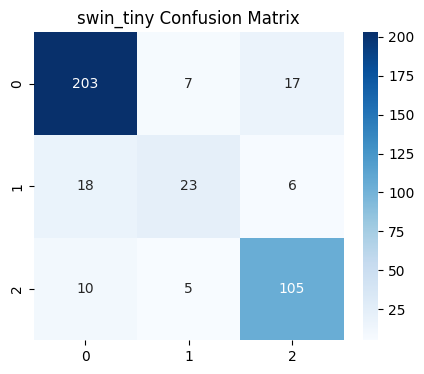

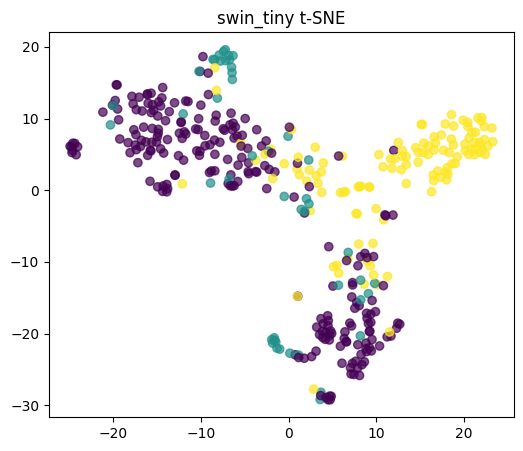

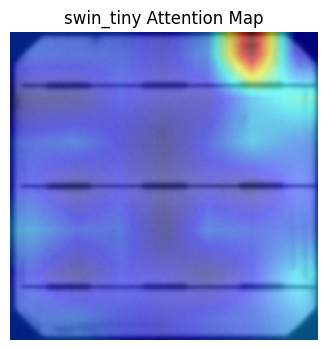

 Saved swin_tiny_best.pth to Drive!


In [ ]:
train_and_evaluate('swin_tiny')
run_visualizations('swin_tiny')


import shutil
import os
drive_path = '/content/drive/MyDrive/SASIGD_Models'
os.makedirs(drive_path, exist_ok=True)

if os.path.exists('swin_tiny_best.pth'):
    shutil.copy('swin_tiny_best.pth', os.path.join(drive_path, 'swin_tiny_best.pth'))
    print(f" Saved swin_tiny_best.pth to Drive!")

In [ ]:
import pandas as pd
import numpy as np
import glob
import os

drive_path = '/content/drive/MyDrive/SASIGD_Models'
print(f" Scanning {drive_path} for Brains...\n")

csv_files = glob.glob(os.path.join(drive_path, '*_features.csv'))
csv_files.sort()

if not csv_files:
    print(" No CSVs found! Make sure you ran the Extraction Step first.")
else:
    print(f" Found {len(csv_files)} Models. Generating Rules now...\n")

for filepath in csv_files:
    model_name = os.path.basename(filepath).replace('_features.csv', '').upper()

    df = pd.read_csv(filepath)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    drop_cols = ['true_label', 'conf_mild', 'conf_severe', 'pred_prob_mild', 'pred_prob_severe']
    clean_cols = [c for c in numeric_cols if c not in drop_cols]

    correlations = df[clean_cols].corrwith(df['true_label']).abs()
    best_feat = correlations.idxmax()
    best_corr = correlations.max()

    avg_mild = df[df['true_label'] == 1][best_feat].mean()
    avg_severe = df[df['true_label'] == 2][best_feat].mean()
    threshold = (avg_mild + avg_severe) / 2

    print(f" MODEL: {model_name}")
    print(f"   ► Key Feature Detected: '{best_feat}' (Correlation: {best_corr:.2f})")
    print(f"   ► Fuzzy Logic Rules:")

    if avg_mild < avg_severe:

        print(f"      1. IF {best_feat} is LOW  (< {threshold:.3f}) THEN Severity is MILD.")
        print(f"      2. IF {best_feat} is HIGH (> {threshold:.3f}) THEN Severity is SEVERE.")
    else:

        print(f"      1. IF {best_feat} is HIGH (> {threshold:.3f}) THEN Severity is MILD.")
        print(f"      2. IF {best_feat} is LOW  (< {threshold:.3f}) THEN Severity is SEVERE.")


print("\nDONE'.")

 Scanning /content/drive/MyDrive/SASIGD_Models for Brains...

 Found 3 Models. Generating Rules now...

 MODEL: CONVNEXT_TINY
   ► Key Feature Detected: 'f487' (Correlation: 0.82)
   ► Fuzzy Logic Rules:
      1. IF f487 is HIGH (> -19.180) THEN Severity is MILD.
      2. IF f487 is LOW  (< -19.180) THEN Severity is SEVERE.
 MODEL: EFFICIENTNET_B0
   ► Key Feature Detected: 'f199' (Correlation: 0.42)
   ► Fuzzy Logic Rules:
      1. IF f199 is LOW  (< 0.186) THEN Severity is MILD.
      2. IF f199 is HIGH (> 0.186) THEN Severity is SEVERE.
 MODEL: RESNET50
   ► Key Feature Detected: 'f1555' (Correlation: 0.64)
   ► Fuzzy Logic Rules:
      1. IF f1555 is LOW  (< 0.244) THEN Severity is MILD.
      2. IF f1555 is HIGH (> 0.244) THEN Severity is SEVERE.

DONE'.


In [4]:
import pandas as pd
import numpy as np
import glob
import os


drive_path = '/content/drive/MyDrive/SASIGD_Models'
print(f" Scanning {drive_path}\n")


csv_files = glob.glob(os.path.join(drive_path, '*_features.csv'))
csv_files.sort()

if not csv_files:
    print(" No CSVs found")
else:
    print(f"Generating Rules now\n")


for filepath in csv_files:

    model_name = os.path.basename(filepath).replace('_features.csv', '').upper()


    df = pd.read_csv(filepath)


    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    drop_cols = ['true_label', 'conf_mild', 'conf_severe', 'pred_prob_mild', 'pred_prob_severe']
    clean_cols = [c for c in numeric_cols if c not in drop_cols]


    correlations = df[clean_cols].corrwith(df['true_label']).abs()
    best_feat = correlations.idxmax()
    best_corr = correlations.max()


    avg_mild = df[df['true_label'] == 1][best_feat].mean()
    avg_severe = df[df['true_label'] == 2][best_feat].mean()
    threshold = (avg_mild + avg_severe) / 2


    print(f" MODEL: {model_name}")
    print(f"   ► Key Feature Detected: '{best_feat}' (Correlation: {best_corr:.2f})")
    print(f"   ► Fuzzy Logic Rules:")


    if avg_mild < avg_severe:

        print(f"      1. IF {best_feat} is LOW  (< {threshold:.3f}) THEN Severity is MILD.")
        print(f"      2. IF {best_feat} is HIGH (> {threshold:.3f}) THEN Severity is SEVERE.")
    else:

        print(f"      1. IF {best_feat} is HIGH (> {threshold:.3f}) THEN Severity is MILD.")
        print(f"      2. IF {best_feat} is LOW  (< {threshold:.3f}) THEN Severity is SEVERE.")


print("\n IF-THEN rules...")


Scanning /content/drive/MyDrive/SASIGD_Models

Generating Rules now...

MODEL: SWIN_TINY
  ► Key Feature Detected: 'f101' (Correlation: 0.78)
  ► Fuzzy Logic Rules:
     1. IF f101 is LOW  (< 1.445) THEN Severity is MILD.
     2. IF f101 is HIGH (> 1.445) THEN Severity is SEVERE.
 
 IF-THEN rules...

